## Turma: DADOS - 2025.2

## Materia: RNA e Deep Learning

### Nome: Wagner Ferreira Porto de Vasconcelos


# Rede neural com camadas escondidas - Classificação do Iris dataset

O objetivo desse experimento é ilustrar o uso de rede neural que tenha mais de uma camada. Isso é conseguido com a inserção de uma ativação não linear entre as camadas.

Datasets utilizados:
    - Iris - 3 classes
    - Sintéticos:
        - meia luas
        - círculos circunscritos
        - blobs

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/Net2RegressaoSoftmaxArgmaxRede.png)

## Importando as bibliotecas

In [1]:
%matplotlib inline
from sklearn import datasets
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable
import torch.nn as nn

## Leitura, normalização e visualização dos dados

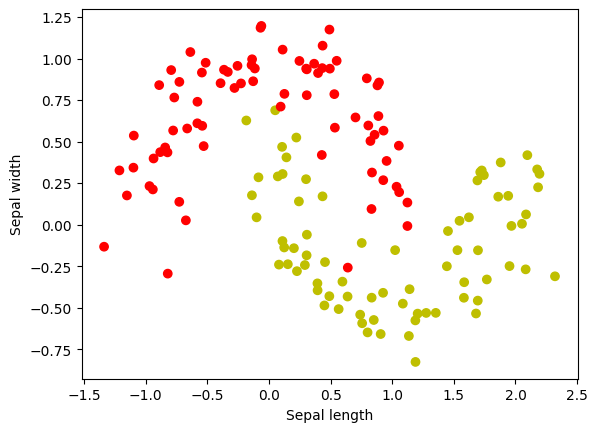

In [2]:
n_samples = 150
options = ['iris', 'moon', 'circles', 'blobs']
option = options[1]
if option == 'iris':
    iris = datasets.load_iris()
    X = iris.data[:,:2]  # comprimento das sépalas e pétalas, indices 0 e 2
    Xc = X - X.min(axis=0)
    Xc /= Xc.max(axis=0)
    Y = iris.target
elif option == 'moon':
    Xc,Y = datasets.make_moons(n_samples=n_samples, noise=.15)
elif option == 'circles':
    Xc,Y = datasets.make_circles(n_samples=n_samples, factor=.5, noise=.1)
elif option == 'blobs':
    Xc,Y = datasets.make_blobs(n_samples=n_samples,centers=3,cluster_std=1.2)

colors = np.array(['r','y','b'])
plt.scatter(Xc[:, 0], Xc[:, 1], c=colors[Y])
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.show()

### Prepara os dados para o PyTorch

In [3]:
X_tensor = torch.FloatTensor(Xc)
Y_tensor = torch.LongTensor(Y)

## Construindo o modelo da rede

In [4]:
class Modelo(nn.Module):
    def __init__(self):
        super(Modelo, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 5),
            nn.ReLU(),
            nn.Linear(5, 5),
            nn.ReLU(),
            nn.Linear(5,3),
        )

    def forward(self, x):
        x = self.dense(x)

        return x

model = Modelo()
print(model)

Modelo(
  (dense): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=3, bias=True)
  )
)


## _predict_ utilizada para predição de classes e na visualização

In [5]:
def predict(model, inputs):
    outputs = model(Variable(inputs))
    _, predicts = torch.max(outputs, 1)

    return predicts.data.numpy()

## Classe para visualização dinâmica

In [6]:
class BoundaryPlotter():
    def __init__(self, model, X, Y, n_epoch, filepath=None, h = .01):
        self.model = model
        self.X = X
        self.Y = Y
        self.n_epoch = n_epoch
        self.filepath = filepath
        x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
        y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
        self.xx, self.yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        self.loss_hist = []
        self.val_loss_hist = []
        self.X_grid = np.c_[self.xx.ravel(), self.yy.ravel()]

        #Gráficos a serem mostrados pelo callback
        self.fig = plt.figure(figsize=(8, 4), dpi=100)
        self.ax1 = self.fig.add_subplot(1, 2, 1)
        self.ax1.set_xlim(0, nb_epoch)
        self.ax1.set_xlabel('Epoca')#,fontsize=28)
        self.ax1.set_ylabel('Perda')#,fontsize=28)
        self.ax1.plot([],[],'b',linewidth = 2.0,label = "Treino")
        self.ax1.grid(True)

        self.ax2 = self.fig.add_subplot(1, 2, 2)
        self.ax2.set_xlim(Xc[:,0].min(), Xc[:,0].max())
        self.ax2.set_ylim(Xc[:,1].min(), Xc[:,1].max())
        self.ax2.set_xlabel('Comprimento da Sepala')#,fontsize=28)
        self.ax2.set_ylabel('Largura da Sepala')#,fontsize=28)

    def on_train_begin(self, logs={}):
        display.display(self.fig)
        display.clear_output(wait=True)

    def on_epoch_end(self, epoch, logs={}):
        if 'loss' in logs.keys():
            self.loss_hist.append(logs['loss'])

            if epoch%250==0:
                self.ax1.plot(np.arange(epoch+1), self.loss_hist, 'b', linewidth = 2.0)

                Z = predict(self.model, torch.from_numpy(self.X_grid).type(torch.FloatTensor))
#                 Z = torch.max(self.model(Variable(torch.FloatTensor(self.X_grid))).data, dim=1)[1].numpy()
                Z = Z.reshape(self.xx.shape)

                self.ax2.pcolormesh(self.xx, self.yy, Z, cmap=plt.cm.Paired)
                colors = np.array(['r','y','b'])
                self.ax2.scatter(self.X[:, 0], self.X[:, 1], s=40, c=colors[self.Y], edgecolors='k', cmap=plt.cm.Paired)

                display.display(self.fig)
                display.clear_output(wait=True)

## Treinamento

In [7]:
lr = 0.15

optimizer = torch.optim.SGD(model.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

### Laço principal de treinamento

Final loss: tensor(0.2348)


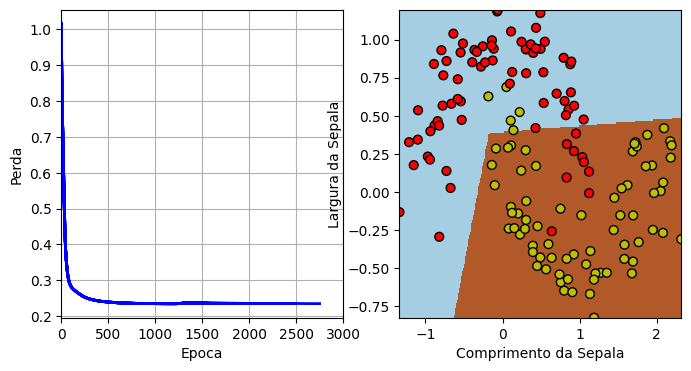

In [8]:
batch_size = 150
nb_epoch = 3000

#Definindo o plotter
boundary_plot = BoundaryPlotter(model, Xc, Y, nb_epoch)

boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    # predict da rede
    output = model(Variable(X_tensor))

    loss = criterion(output, Variable(Y_tensor))

    # zero, backpropagation gradient, atualiza param gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data)

    boundary_plot.on_epoch_end(i, {'loss': loss.data})

print('Final loss:', loss.data)

## Avaliação

### Imprimindo pesos finais

In [9]:
for name, w in model.state_dict().items():
    print('{:16}{}'.format(name, w.size()))
    print(w)

dense.0.weight  torch.Size([5, 2])
tensor([[ 0.9362,  0.0931],
        [ 0.7858, -0.7584],
        [-1.7997, -0.0051],
        [-0.2053,  0.6778],
        [ 0.7291,  0.0656]])
dense.0.bias    torch.Size([5])
tensor([ 0.1184,  1.3133, -0.3270,  0.7061,  0.0964])
dense.2.weight  torch.Size([5, 5])
tensor([[-0.1509,  0.5586, -0.7894, -0.1701,  0.2381],
        [-0.1052,  1.2827, -0.5934, -0.3418, -0.3923],
        [ 0.6118, -0.4725,  0.6067,  0.4299, -0.0339],
        [ 0.5587,  0.0721,  1.4156,  0.9284,  0.4396],
        [-0.4601,  0.8631, -0.1076, -0.0278, -0.4321]])
dense.2.bias    torch.Size([5])
tensor([0.7467, 0.7416, 0.2390, 0.8080, 0.0016])
dense.4.weight  torch.Size([3, 5])
tensor([[-0.2159, -0.6983,  0.4622,  1.3245, -0.5893],
        [ 0.8694,  1.0427, -0.5591, -0.8094,  0.4699],
        [-0.6086, -0.8655, -0.5475, -1.1433, -0.2173]])
dense.4.bias    torch.Size([3])
tensor([ 0.6891, -0.0036, -0.8531])


### Avaliação do classificador

In [10]:
Y_hat = predict(model, X_tensor)
accuracy = (Y_hat == Y).mean()
print()
print('Training Accuracy: ', accuracy)


Training Accuracy:  0.9066666666666666


### Matriz de confusão

In [11]:
import pandas as pd
pd.crosstab(Y_hat, Y)

col_0,0,1
row_0,,
0,67,6
1,8,69


## Atividades

### Experimentos:

1. Faça alterações na rede, alterando o número de neurônios, de camadas. Escreva suas conclusões.

Loss final Exp1: tensor(0.2286)
Acurácia Exp1: 0.9


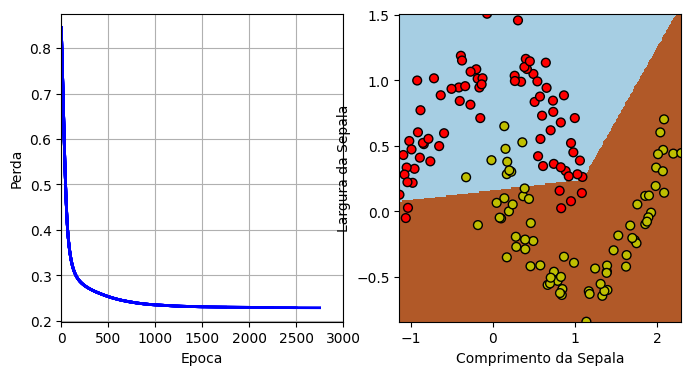

In [12]:
# Experimento 1: rede mínima — 1 camada escondida, 2 neurônios
option = 'moon'
Xc, Y = datasets.make_moons(n_samples=150, noise=.15)

X_tensor = torch.FloatTensor(Xc)
Y_tensor = torch.LongTensor(Y)

class Modelo_Exp1(nn.Module):
    def __init__(self):
        super(Modelo_Exp1, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 2),
            nn.ReLU(),
            nn.Linear(2, 3),
        )
    def forward(self, x):
        return self.dense(x)

model_exp1 = Modelo_Exp1()
print(model_exp1)

optimizer = torch.optim.SGD(model_exp1.parameters(), lr=0.15)
criterion = nn.CrossEntropyLoss()

nb_epoch = 3000
boundary_plot = BoundaryPlotter(model_exp1, Xc, Y, nb_epoch)
boundary_plot.on_train_begin()
losses_exp1 = []

for i in range(nb_epoch):
    output = model_exp1(Variable(X_tensor))
    loss = criterion(output, Variable(Y_tensor))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses_exp1.append(loss.data)
    boundary_plot.on_epoch_end(i, {'loss': loss.data})

print('Loss final Exp1:', loss.data)
Y_hat1 = predict(model_exp1, X_tensor)
print('Acurácia Exp1:', (Y_hat1 == Y).mean())

Loss final Exp3: tensor(0.0017)
Acurácia Exp3: 1.0


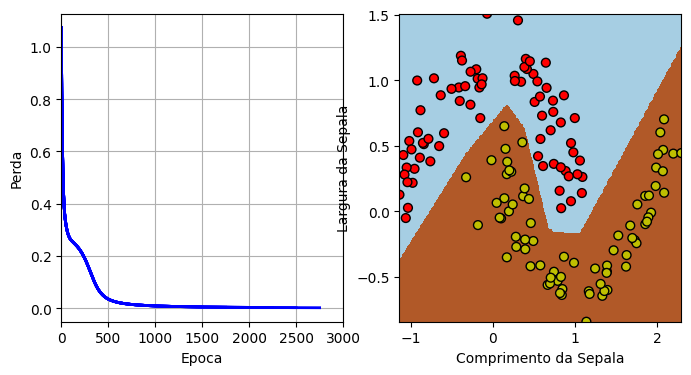

In [13]:
# Experimento 2: mais neurônios — 2 camadas, 20 neurônios
class Modelo_Exp3(nn.Module):
    def __init__(self):
        super(Modelo_Exp3, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 20),
            nn.ReLU(),
            nn.Linear(20, 20),
            nn.ReLU(),
            nn.Linear(20, 3),
        )
    def forward(self, x):
        return self.dense(x)

model_exp3 = Modelo_Exp3()
print(model_exp3)

optimizer = torch.optim.SGD(model_exp3.parameters(), lr=0.15)
criterion = nn.CrossEntropyLoss()

nb_epoch = 3000
boundary_plot = BoundaryPlotter(model_exp3, Xc, Y, nb_epoch)
boundary_plot.on_train_begin()
losses_exp3 = []

for i in range(nb_epoch):
    output = model_exp3(Variable(X_tensor))
    loss = criterion(output, Variable(Y_tensor))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses_exp3.append(loss.data)
    boundary_plot.on_epoch_end(i, {'loss': loss.data})

print('Loss final Exp2:', loss.data)
Y_hat3 = predict(model_exp3, X_tensor)
print('Acurácia Exp2:', (Y_hat3 == Y).mean())

Loss final Exp3: tensor(0.0002)
Acurácia Exp3: 1.0


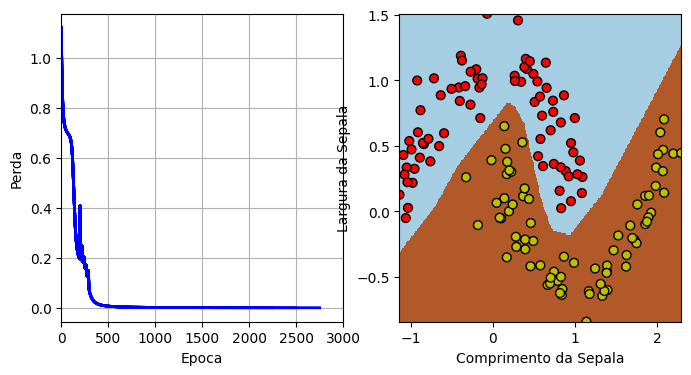

In [14]:
# Experimento 3: mais camadas — 4 camadas, 10 neurônios
class Modelo_Exp4(nn.Module):
    def __init__(self):
        super(Modelo_Exp4, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.ReLU(),
            nn.Linear(10, 3),
        )
    def forward(self, x):
        return self.dense(x)

model_exp4 = Modelo_Exp4()
print(model_exp4)

optimizer = torch.optim.SGD(model_exp4.parameters(), lr=0.15)
criterion = nn.CrossEntropyLoss()

nb_epoch = 3000
boundary_plot = BoundaryPlotter(model_exp4, Xc, Y, nb_epoch)
boundary_plot.on_train_begin()
losses_exp4 = []

for i in range(nb_epoch):
    output = model_exp4(Variable(X_tensor))
    loss = criterion(output, Variable(Y_tensor))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses_exp4.append(loss.data)
    boundary_plot.on_epoch_end(i, {'loss': loss.data})

print('Loss final Exp3:', loss.data)
Y_hat4 = predict(model_exp4, X_tensor)
print('Acurácia Exp3:', (Y_hat4 == Y).mean())

## Conclusões

Experimento 1

Mostrou que a rede com apenas 2 neurônios não consegue separar as meia-luas — a fronteira fica quase reta, o que não resolve o problema.

Experimento 2

Melhorou ainda mais: com 20 neurônios por camada a rede convergiu mais rápido e com perda menor. Aumentar a largura ajudou bastante aqui.

Experimento 3

 Aprendeu bem, mas a convergência foi mais lenta. Para um problema simples como o moon, profundidade extra não traz tanto ganho quanto aumentar os neurônios — e pode dificultar o treinamento com SGD simples.

2. No lugar da ReLU, coloque Sigmoid e observe a diferença. O que aconteceu? Descreva.

R: A ReLU aprendeu mais rápido e acertou melhor a separação dos dados. No gráfico dá pra ver que a perda dela caiu bem mais rápido do que a da Sigmoid. A Sigmoid foi mais lenta e em alguns casos a rede quase não evoluiu. Isso acontece porque ela "amortece" as correções que a rede precisa fazer durante o treino, quanto mais camadas, pior fica, porque esse efeito vai se acumulando. No final, para esse tipo de problema, a ReLU funcionou melhor. A Sigmoid ainda pode ser útil em casos específicos, mas no geral foi substituída pela ReLU justamente por esse comportamento.


3. O que ocorre quando não se utiliza ativação não linear entre camadas?

R: Sem ativação a rede só consegue traçar uma linha reta, e linha reta não separa dados curvos, não importa quantas camadas foram adicionadas